# Configuración básica (no tocar)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from abstractions.base import Function
from abstractions.functions import Variable, sin, cos, exp, ln

In [2]:
x = Variable()

# Implementación de métodos

In [3]:
# Implementar para hallar raíces de las derivadas, no de f

def biseccion(f: Function, a: float, b: float, tol: float = 1e-6, max_iter: int = 1000):
    df = f.derivative()
    fa = df.eval(a)
    fb = df.eval(b)

    if fa * fb > 0:
        raise ValueError("La derivada no cambia de signo en [a, b]")

    c = a
    for step in range(1, max_iter + 1):
        c = (a + b) / 2
        fc = df.eval(c)

        if abs(fc) < tol or (b - a) / 2 < tol:
            return c, step

        if fa * fc < 0:
            b = c
        else:
            a = c
            fa = fc

    return c, max_iter


def newton(f: Function, x0: float, tol: float = 1e-6, max_iter: int = 1000):
    df = f.derivative()
    d2f = df.derivative()
    xn = x0

    for step in range(1, max_iter + 1):
        segunda_derivada = d2f.eval(xn)
        if abs(segunda_derivada) < 1e-12:
            raise ValueError("Segunda derivada nula, método no aplicable")

        desplazamiento = df.eval(xn) / segunda_derivada
        xn = xn - desplazamiento

        if abs(desplazamiento) < tol:
            return xn, step

    return xn, max_iter


def descenso_gradiente(f: Function, x0: float, lr: float, tol: float = 1e-6, max_iter: int = 1000):
    df = f.derivative()
    xn = x0

    for step in range(1, max_iter + 1):
        siguiente = xn - lr * df.eval(xn)

        if abs(siguiente - xn) < tol:
            return siguiente, step

        xn = siguiente

    return xn, max_iter

### Prueba de métodos

f(x) = x^2 Bisección x = 0.000000 iteraciones = 1
f(x) = x^2 Newton x = 0.000000 iteraciones = 2
f(x) = x^2 Descenso x = 0.000048 iteraciones = 492
f(x) = (x + 0.5)^3 - x - 0.5 Bisección x = 0.077350 iteraciones = 21
f(x) = (x + 0.5)^3 - x - 0.5 Newton x = 0.077350 iteraciones = 6
f(x) = (x + 0.5)^3 - x - 0.5 Descenso x = 0.077378 iteraciones = 278
f(x) = -cos(x) Bisección x = 0.000000 iteraciones = 1
f(x) = -cos(x) Newton x = 0.000000 iteraciones = 5
f(x) = -cos(x) Descenso x = 0.000098 iteraciones = 927


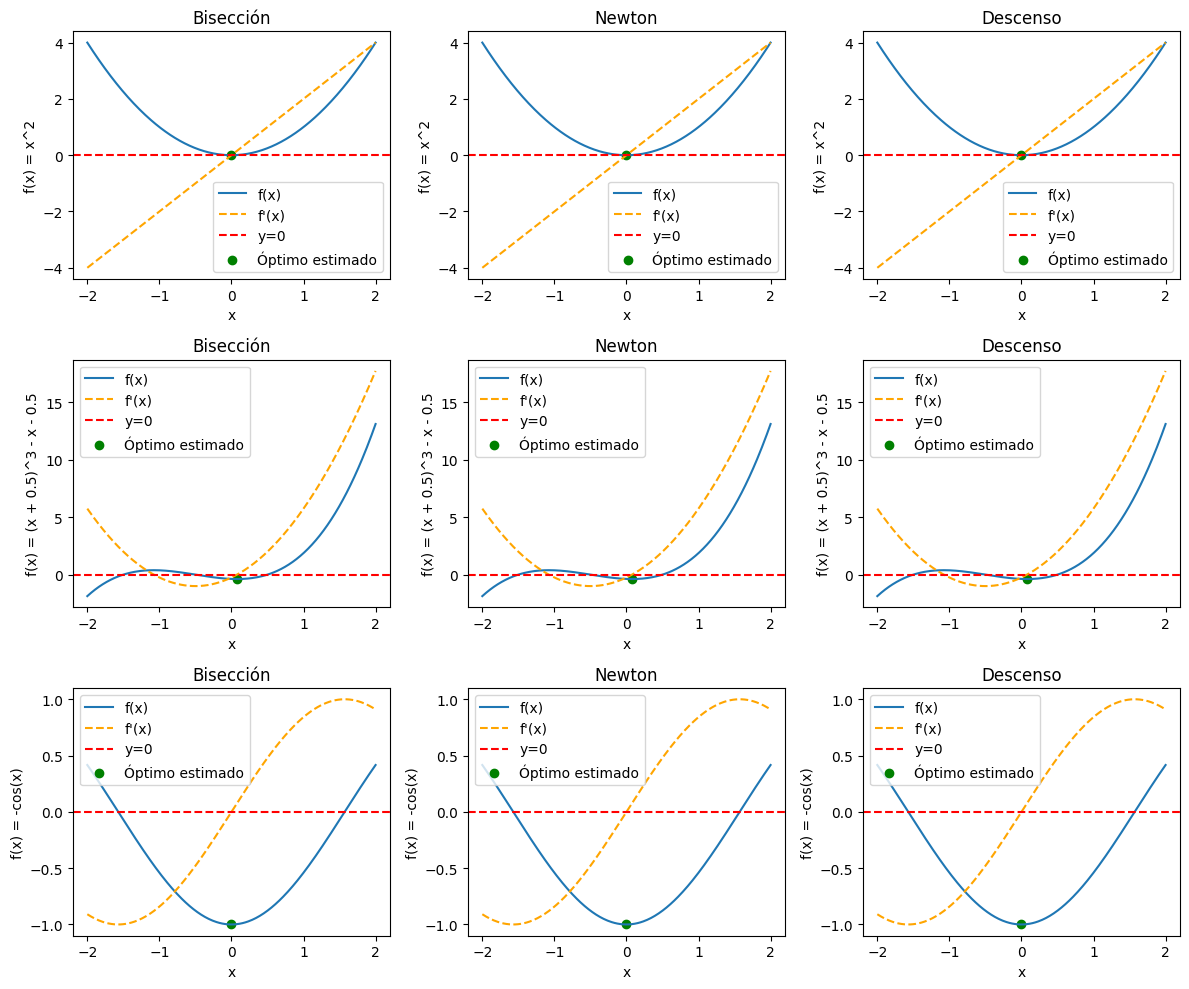

In [4]:
f1 = x**2
f2 = (x + 0.5)**3 - x - 0.5
f3 = -cos(x)

functions = [f1, f2, f3]

methods = [biseccion, newton, descenso_gradiente]
# Recomendación: exploren parámetros en esta etapa para ver distintos comportamientos.
parameters = [{"a":-1, "b":1}, {"x0": 1}, {"x0": 1, "lr": 1e-2}]

y_labels = ["f(x) = x^2", "f(x) = (x + 0.5)^3 - x - 0.5", "f(x) = -cos(x)"]
titles = ["Bisección", "Newton", "Descenso"]

lp = np.linspace(-2, 2, 300)

fig, axes = plt.subplots(3, 3, figsize=(12, 10))

for i, f in enumerate(functions):
    for j, m in enumerate(methods):
        ax = axes[i, j]
        # labels ejes
        ax.set_xlabel("x")
        ax.set_ylabel(y_labels[i])

        # métodos
        method = methods[j]
        params = parameters[j] 
        res, step = method(f, **params)
        print(y_labels[i], titles[j], f"x = {res:.6f}", f"iteraciones = {step}")

        # graficas
        ax.plot(lp, np.array(list(map(lambda v: f.eval(v), lp))))
        ax.plot(lp, np.array(list(map(lambda v: f.derivative().eval(v), lp))), linestyle="--", color="orange")
        ax.axhline(0, linestyle="--", color="red")
        ax.scatter(res, f.eval(res), color="green")

        ax.plot()
        ax.legend([f"f(x)", "f'(x)", "y=0", "Óptimo estimado"])
        ax.set_title(titles[j])

plt.tight_layout()
plt.show()

# Aplicación a función no trivial

In [5]:
f = x**2 + 2*sin(3*x)

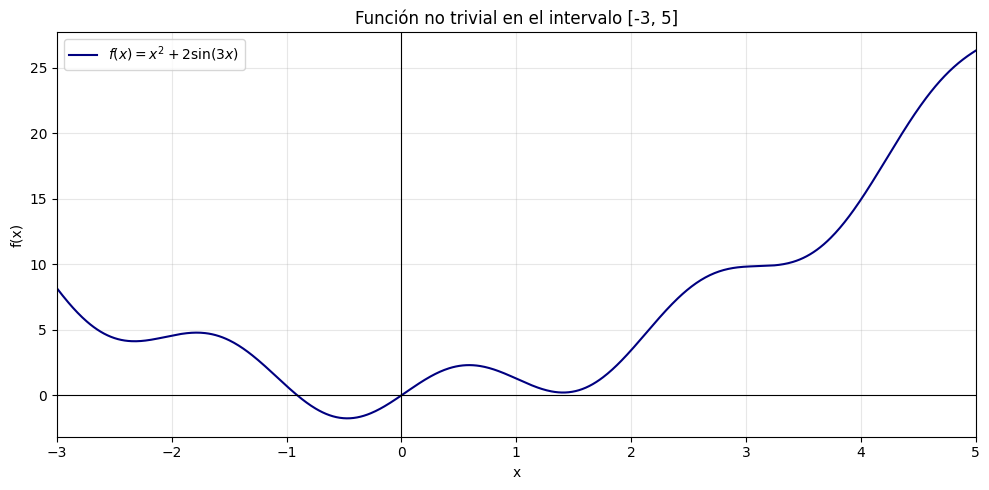

In [6]:
# Gráfica de la función en el intervalo pedido
puntos_x = np.linspace(-3, 5, 800)
puntos_y = np.array([f.eval(valor) for valor in puntos_x])

plt.figure(figsize=(10, 5))
plt.plot(puntos_x, puntos_y, color="navy", label=r"$f(x)=x^2+2\sin(3x)$")
plt.axhline(0, color="black", linewidth=0.8)
plt.axvline(0, color="black", linewidth=0.8)
plt.xlim(-3, 5)
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Función no trivial en el intervalo [-3, 5]")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("figura_parte3.png", dpi=180, bbox_inches="tight")
plt.show()

In [7]:
# Evaluación de métodos y generación de la tabla principal
from IPython.display import display

df = f.derivative()
d2f = df.derivative()

tolerancia_metodos = 1e-8
tolerancia_residuo = 1e-6
max_iteraciones = 1000

def clasificar_punto(valor):
    curvatura = d2f.eval(valor)
    if curvatura > 0:
        return "mínimo local"
    if curvatura < 0:
        return "máximo local"
    return "clasificación inconclusa"

experimentos = [
    ("Bisección", "[-2, 1]", lambda: biseccion(f, -2, 1, tolerancia_metodos, max_iteraciones)),
    ("Bisección", "[-1, 0]", lambda: biseccion(f, -1, 0, tolerancia_metodos, max_iteraciones)),
    ("Bisección", "[1, 2]", lambda: biseccion(f, 1, 2, tolerancia_metodos, max_iteraciones)),
    ("Newton", "x0 = -2", lambda: newton(f, -2, tolerancia_metodos, max_iteraciones)),
    ("Newton", "x0 = -1", lambda: newton(f, -1, tolerancia_metodos, max_iteraciones)),
    ("Newton", "x0 = 4", lambda: newton(f, 4, tolerancia_metodos, max_iteraciones)),
    ("Gradiente", "x0 = -3, α = 0.05", lambda: descenso_gradiente(f, -3, 0.05, tolerancia_metodos, max_iteraciones)),
    ("Gradiente", "x0 = 0.585, α = 0.05", lambda: descenso_gradiente(f, 0.585, 0.05, tolerancia_metodos, max_iteraciones)),
    ("Gradiente", "x0 = 4, α = 0.05", lambda: descenso_gradiente(f, 4, 0.05, tolerancia_metodos, max_iteraciones)),
]

filas_resultados = []
for metodo, condicion, ejecutar in experimentos:
    aproximacion, iteraciones = ejecutar()
    residuo = abs(df.eval(aproximacion))
    convergio = iteraciones < max_iteraciones and residuo < tolerancia_residuo
    filas_resultados.append({
        "Método": metodo,
        "Condición inicial": condicion,
        "Aproximación": aproximacion,
        "Iteraciones": iteraciones,
        "Residuo |f'(x)|": residuo,
        "Estado": "Converge" if convergio else "No converge",
        "Clasificación": clasificar_punto(aproximacion) if convergio else "No corresponde",
    })

tabla_resultados = pd.DataFrame(filas_resultados)
display(tabla_resultados.style.format({
    "Aproximación": "{:.9f}",
    "Residuo |f'(x)|": "{:.3e}",
}))

,Método,Condición inicial,Aproximación,Iteraciones,Residuo |f'(x)|,Estado,Clasificación
0,Bisección,"[-2, 1]",-1.782932473,29,2.345e-08,Converge,máximo local
1,Bisección,"[-1, 0]",-0.471043177,27,1.198e-07,Converge,mínimo local
2,Bisección,"[1, 2]",1.407956578,27,2.235e-08,Converge,mínimo local
3,Newton,x0 = -2,-1.782932475,6,8.882e-16,Converge,máximo local
4,Newton,x0 = -1,0.589531341,6,6.661e-16,Converge,máximo local
5,Newton,x0 = 4,7.820891884,1000,1.505e+01,No converge,No corresponde
6,Gradiente,"x0 = -3, α = 0.05",-2.322807411,16,5.333e-08,Converge,mínimo local
7,Gradiente,"x0 = 0.585, α = 0.05",-0.471043171,15,4.856e-10,Converge,mínimo local
8,Gradiente,"x0 = 4, α = 0.05",1.407956578,32,1.664e-08,Converge,mínimo local


In [8]:
# Comparación de learning rates para descenso por gradiente
def descenso_gradiente_residuo(f_objetivo, x0, lr, tol=1e-6, max_iter=1000):
    df_objetivo = f_objetivo.derivative()
    xn = x0

    if abs(df_objetivo.eval(xn)) < tol:
        return xn, 0

    for step in range(1, max_iter + 1):
        siguiente = xn - lr * df_objetivo.eval(xn)
        if not np.isfinite(siguiente):
            return siguiente, step
        if abs(df_objetivo.eval(siguiente)) < tol:
            return siguiente, step
        xn = siguiente

    return xn, max_iter

learning_rates = [0.01, 0.05, 0.10, 0.20]
inicios_gradiente = [-3, 0.585, 4]
filas_lr = []

for learning_rate in learning_rates:
    for inicio in inicios_gradiente:
        aproximacion, iteraciones = descenso_gradiente_residuo(
            f, inicio, learning_rate, tolerancia_residuo, max_iteraciones
        )
        residuo = abs(df.eval(aproximacion))
        convergio = iteraciones < max_iteraciones and residuo < tolerancia_residuo
        filas_lr.append({
            "x0": inicio,
            "Learning rate": learning_rate,
            "Último x": aproximacion,
            "Residuo |f'(x)|": residuo,
            "Estado": "Converge" if convergio else "No converge",
            "Clasificación": clasificar_punto(aproximacion) if convergio else "No corresponde",
            "Iteraciones": iteraciones,
        })

tabla_learning_rates = pd.DataFrame(filas_lr)
display(tabla_learning_rates.style.format({
    "Último x": "{:.9f}",
    "Learning rate": "{:.2f}",
    "Residuo |f'(x)|": "{:.3e}",
}))

,x0,Learning rate,Último x,Residuo |f'(x)|,Estado,Clasificación,Iteraciones
0,-3.000000,0.01,-2.322807474,8.896e-07,Converge,mínimo local,108
1,0.585000,0.01,-0.471043124,9.215e-07,Converge,mínimo local,109
2,4.000000,0.01,1.407956628,9.289e-07,Converge,mínimo local,202
3,-3.000000,0.05,-2.322807444,4.884e-07,Converge,mínimo local,14
4,0.585000,0.05,-0.471043169,4.350e-08,Converge,mínimo local,14
5,4.000000,0.05,1.407956585,1.581e-07,Converge,mínimo local,31
6,-3.000000,0.10,-2.322807438,4.126e-07,Converge,mínimo local,17
7,0.585000,0.10,-0.471043221,9.985e-07,Converge,mínimo local,612
8,4.000000,0.10,1.407956531,8.106e-07,Converge,mínimo local,63
9,-3.000000,0.20,0.337657079,3.851e+00,No converge,No corresponde,1000


In [9]:
# Búsqueda de máximos aplicando el mismo algoritmo a -f
filas_maximos = []
for inicio in inicios_gradiente:
    aproximacion, iteraciones = descenso_gradiente_residuo(
        -f, inicio, 0.05, tolerancia_residuo, 200
    )
    residuo = abs(df.eval(aproximacion))
    convergio = iteraciones < 200 and residuo < tolerancia_residuo
    filas_maximos.append({
        "x0": inicio,
        "Último x": aproximacion,
        "f(Último x)": f.eval(aproximacion),
        "Residuo |f'(x)|": residuo,
        "Estado": "Converge" if convergio else "No converge",
        "Clasificación para f": clasificar_punto(aproximacion) if convergio else "No corresponde",
        "Iteraciones": iteraciones,
    })

tabla_maximos = pd.DataFrame(filas_maximos)
display(tabla_maximos.style.format({
    "Último x": "{:.6e}",
    "f(Último x)": "{:.6e}",
    "Residuo |f'(x)|": "{:.3e}",
}))

,x0,Último x,f(Último x),Residuo |f'(x)|,Estado,Clasificación para f,Iteraciones
0,-3.000000,-4.780552e+08,2.285368e+17,9.561e+08,No converge,No corresponde,200
1,0.585000,5.895313e-01,2.308551e+00,3.533e-07,Converge,máximo local,8
2,4.000000,7.272879e+08,5.289477e+17,1.455e+09,No converge,No corresponde,200


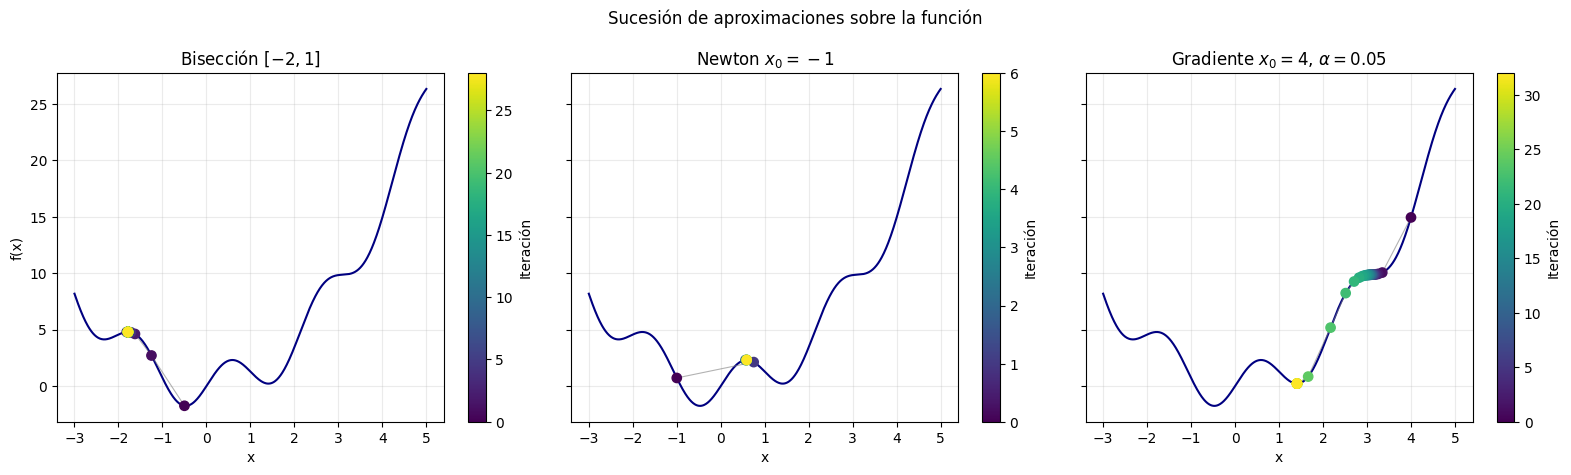

In [10]:
# BONUS parte 3.2: sucesión de aproximaciones
# Se usan variantes auxiliares para no modificar la interfaz de los métodos oficiales.
def biseccion_con_historial(f_objetivo, a, b, tol=1e-6, max_iter=1000):
    df_objetivo = f_objetivo.derivative()
    fa = df_objetivo.eval(a)
    fb = df_objetivo.eval(b)
    historial = []

    if fa * fb > 0:
        raise ValueError("La derivada no cambia de signo en [a, b]")

    c = a
    for step in range(1, max_iter + 1):
        c = (a + b) / 2
        historial.append(c)
        fc = df_objetivo.eval(c)

        if abs(fc) < tol or (b - a) / 2 < tol:
            return c, step, historial

        if fa * fc < 0:
            b = c
        else:
            a = c
            fa = fc

    return c, max_iter, historial


def newton_con_historial(f_objetivo, x0, tol=1e-6, max_iter=1000):
    df_objetivo = f_objetivo.derivative()
    d2f_objetivo = df_objetivo.derivative()
    xn = x0
    historial = [xn]

    for step in range(1, max_iter + 1):
        segunda_derivada = d2f_objetivo.eval(xn)
        if abs(segunda_derivada) < 1e-12:
            raise ValueError("Segunda derivada nula, método no aplicable")

        desplazamiento = df_objetivo.eval(xn) / segunda_derivada
        xn = xn - desplazamiento
        historial.append(xn)

        if abs(desplazamiento) < tol:
            return xn, step, historial

    return xn, max_iter, historial


def descenso_gradiente_con_historial(f_objetivo, x0, lr, tol=1e-6, max_iter=1000):
    df_objetivo = f_objetivo.derivative()
    xn = x0
    historial = [xn]

    for step in range(1, max_iter + 1):
        siguiente = xn - lr * df_objetivo.eval(xn)
        historial.append(siguiente)

        if abs(siguiente - xn) < tol:
            return siguiente, step, historial

        xn = siguiente

    return xn, max_iter, historial


casos_bonus = [
    ("Bisección $[-2,1]$", biseccion_con_historial(f, -2, 1, tolerancia_metodos, max_iteraciones)[2]),
    ("Newton $x_0=-1$", newton_con_historial(f, -1, tolerancia_metodos, max_iteraciones)[2]),
    ("Gradiente $x_0=4$, $\\alpha=0.05$", descenso_gradiente_con_historial(f, 4, 0.05, tolerancia_metodos, max_iteraciones)[2]),
]

x_bonus = np.linspace(-3, 5, 800)
y_bonus = np.array([f.eval(valor) for valor in x_bonus])
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), sharex=True, sharey=True)

for ax, (titulo, historial) in zip(axes, casos_bonus):
    historial = np.array(historial)
    valores = np.array([f.eval(valor) for valor in historial])
    orden = np.arange(len(historial))

    ax.plot(x_bonus, y_bonus, color="navy", linewidth=1.5)
    ax.plot(historial, valores, color="gray", linewidth=0.8, alpha=0.6)
    puntos = ax.scatter(historial, valores, c=orden, cmap="viridis", s=45, zorder=3)
    ax.set_title(titulo)
    ax.set_xlabel("x")
    ax.grid(alpha=0.25)
    fig.colorbar(puntos, ax=ax, label="Iteración")

axes[0].set_ylabel("f(x)")
fig.suptitle("Sucesión de aproximaciones sobre la función")
fig.tight_layout()
plt.savefig("figura_bonus_parte3.png", dpi=180, bbox_inches="tight")
plt.show()

# Ajuste de datos

In [11]:
df_linear = pd.read_csv("datasets/linear_model.csv")
df_exp = pd.read_csv("datasets/exp_model.csv")
df_sin = pd.read_csv("datasets/sin_model.csv")

w = Variable()

In [12]:
# Genere la función de pérdida

In [13]:
# Optimice la función de pérdida

In [14]:
# Grafique datos y ajuste

# BONUS: